Test to see how simpson integration performs

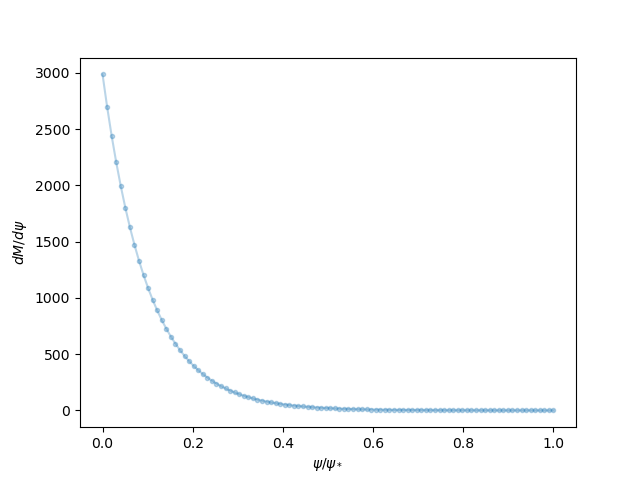

In [1]:
# Do actual PM04 dmdpsi and M(psi)
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson

%matplotlib widget
B_star = 1e8
R_star = 1e4
M_star = 1.4*1.989e30
M_a = 5.e-7*M_star
psi_star = 0.5*B_star*R_star**2
bratio = 10
cs = 1e6
G = 6.67e-11
x0 = (cs*R_star)**2/(G*M_star)
F0 = cs**2*M_a/(x0**3)
psi_0 = np.sqrt(F0)
psi_a = psi_star/bratio
psi = np.linspace(0,psi_star,100)
pm04_dmdpsi = psi_0*0.5/psi_a*np.exp(-psi/psi_a)/(1-np.exp(-bratio))
pm04_mass = 0.5*(1 - np.exp(-psi/psi_a))/(1-np.exp(-bratio))

fig,ax = plt.subplots()
ax.plot(psi/psi_star,pm04_dmdpsi,'.-',alpha  = 0.3)
# ax.plot(psi,pm04_mass,'.-',alpha = 0.4)
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$dM/d\psi$")
plt.show()

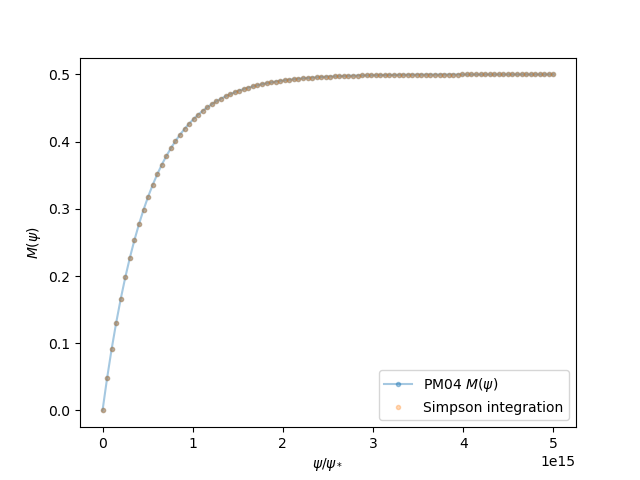

In [2]:
# use simpson integration to calculate cumulative mass, and compare to PM04 M(psi)

cumulative_mass = np.array([simpson(pm04_dmdpsi[:i+1], x=psi[:i+1]/psi_0) for i in range(len(psi))])
fig,ax = plt.subplots()
ax.plot(psi,pm04_mass,'.-',alpha = 0.4,label=r"PM04 $M(\psi)$")
ax.plot(psi,cumulative_mass,'.',alpha  = 0.3,label="Simpson integration")
ax.legend()
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$M(\psi)$")
plt.show()

Now we want to test whether calculating the adjusted mass, modifying dmdpsi, then integrating the modified dmdpsi returns the updated M + dM


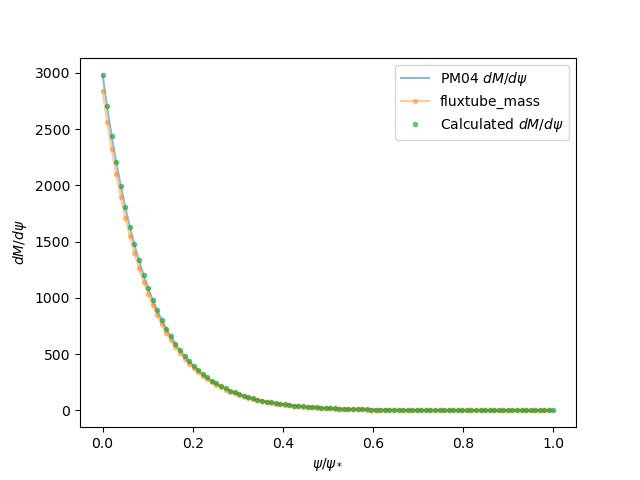

In [8]:
# Compare PM04 dmdpsi to a calculation of dmdpsi by finding gradient of the cumulative mass
%matplotlib widget
fluxtube_mass = cumulative_mass[1:] - cumulative_mass[:-1]
fluxtube_mass = np.append(fluxtube_mass,0)
dmdpsi_calc = np.gradient(cumulative_mass,psi/psi_0,edge_order = 2)

fig,ax = plt.subplots()
ax.plot(psi/psi_star,pm04_dmdpsi,'-',alpha  = 0.5,label=r"PM04 $dM/d\psi$")
ax.plot(psi[:-1]/psi_star,fluxtube_mass[:-1]/((psi[1:] - psi[:-1])/psi_0),'.-',alpha = 0.4,label="fluxtube_mass")
ax.plot(psi/psi_star,dmdpsi_calc,'.',alpha = 0.6,label=r"Calculated $dM/d\psi$")
# ax.plot(psi[:-1]/psi_star,fluxtube_mass,'.-')
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$dM/d\psi$")
ax.legend()
plt.show()

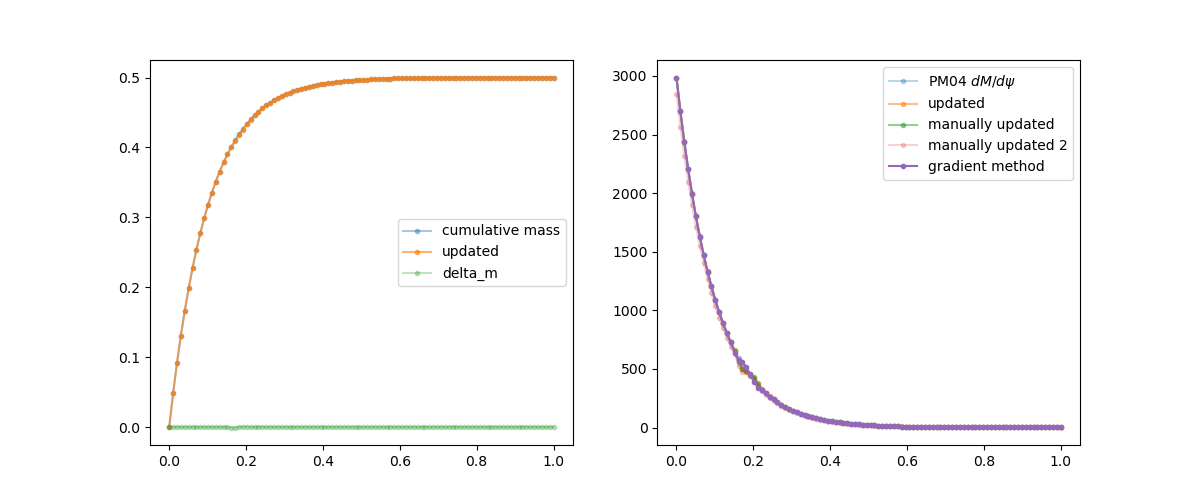

In [55]:
# now update cumulative mass and calculate an updated dmdpsi from it
delta_m = np.zeros_like(psi)
delta_m[20] = 0.1*fluxtube_mass[20]
delta_m[19] = 0.05*fluxtube_mass[20]
delta_m[18] = 0.025*fluxtube_mass[20]
delta_m[21] = 0.025*fluxtube_mass[20]
delta_m[17] = -0.1*fluxtube_mass[20]
delta_m[16] = -0.1*fluxtube_mass[20]

updated_fluxtube_mass = fluxtube_mass + delta_m
updated_mass = np.append(0,np.cumsum(updated_fluxtube_mass))[:-1]# add delta m to the previous cumulative mass

updated_dmdpsi = np.gradient(updated_mass,psi/psi_0, edge_order = 2)
manual_update_dmdpsi = pm04_dmdpsi[:-1] + delta_m[:-1]/((psi[1:] - psi[:-1])/psi_0)
gradient_updated_dmdpsi = pm04_dmdpsi + np.gradient(delta_m,psi/psi_0,edge_order=2)
manual_update_dmdpsi = np.append(manual_update_dmdpsi,pm04_dmdpsi[-1])
manual_2_dmdpsi = np.append(updated_fluxtube_mass[:-1]/((psi[1:] - psi[:-1])/psi_0),0)

fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
ax.plot(psi/psi_star,cumulative_mass,'.-',label="cumulative mass",alpha = 0.4)
ax.plot(psi/psi_star,updated_mass,'.-',label="updated",alpha = 0.6)
ax.plot(psi/psi_star,delta_m,'.-',label="delta_m", alpha = 0.3)
ax.legend()
ax2.plot(psi/psi_star,pm04_dmdpsi,'.-',alpha  = 0.3,label=r"PM04 $dM/d\psi$")
ax2.plot(psi/psi_star,updated_dmdpsi,'.-',alpha = 0.5,label="updated")
ax2.plot(psi/psi_star,manual_update_dmdpsi,'.-',alpha = 0.5,label="manually updated")
ax2.plot(psi/psi_star,manual_2_dmdpsi,'.-',alpha = 0.2,label="manually updated 2")
ax2.plot(psi/psi_star,gradient_updated_dmdpsi,'.-',label= "gradient method")
ax2.legend()
plt.show()

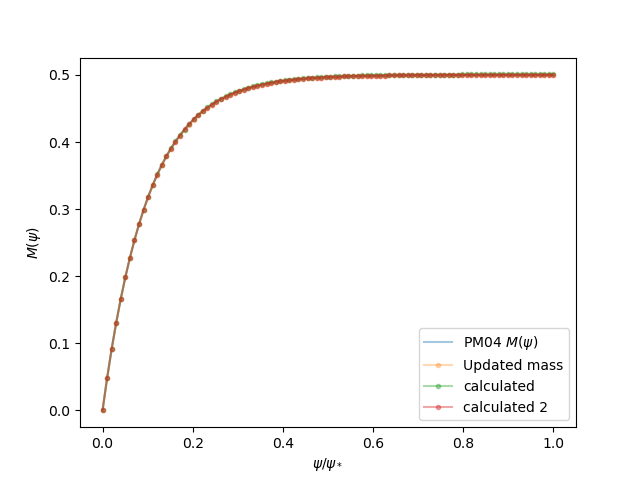

In [57]:
# now integrate dmdpsi to see if we recover the cumulative dmdpsi
integrate_manual_dmdpsi = np.array([simpson(manual_update_dmdpsi[:i+1],x=psi[:i+1]/psi_0) for i in range(len(updated_dmdpsi))])
integrate_dmdpsi = np.array([simpson(updated_dmdpsi[:i+1],x=psi[:i+1]/psi_0) for i in range(len(updated_dmdpsi))])

integrate_gradient_dmdpsi = np.array([simpson(gradient_updated_dmdpsi[:i+1],x=psi[:i+1]/psi_0) for i in range(len(updated_dmdpsi))])

fig,ax = plt.subplots()
ax.plot(psi/psi_star,pm04_mass,'-',alpha = 0.4,label=r"PM04 $M(\psi)$")
ax.plot(psi/psi_star,updated_mass,'.-',alpha  = 0.3,label="Updated mass")
ax.plot(psi/psi_star,integrate_dmdpsi,'.-',alpha = 0.4,label="calculated")
ax.plot(psi/psi_star,integrate_gradient_dmdpsi,'.-',alpha = 0.4,label="calculated 2")
ax.legend()
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$M(\psi)$")
plt.show()

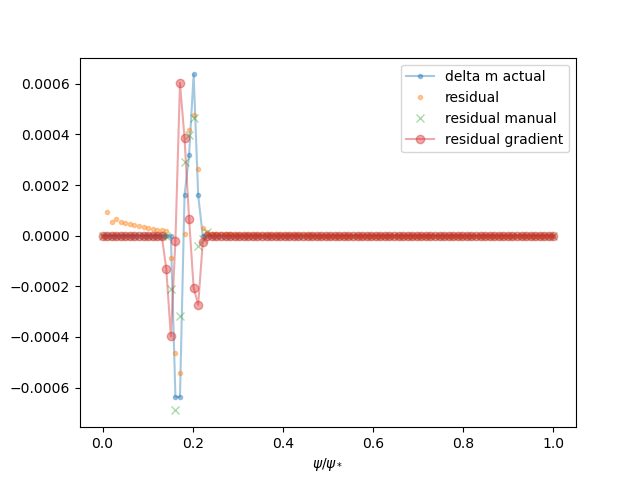

In [59]:
# now check if we can recover the original adjustment by recalculating fluxtube_mass

fluxtube_mass_2 = integrate_dmdpsi[1:] - integrate_dmdpsi[:-1]
fluxtube_mass_2 = np.append(fluxtube_mass_2,0)

fluxtube_mass_manual_2 = integrate_manual_dmdpsi[1:] - integrate_manual_dmdpsi[:-1]
fluxtube_mass_manual_2 = np.append(fluxtube_mass_manual_2,0)

fluxtube_mass_gradient = integrate_gradient_dmdpsi[1:] - integrate_gradient_dmdpsi[:-1]
fluxtube_mass_gradient = np.append(fluxtube_mass_gradient,0)
fig,ax = plt.subplots()
ax.plot(psi/psi_star,delta_m,'.-',alpha = 0.4,label='delta m actual')
ax.plot(psi/psi_star,fluxtube_mass_2 - fluxtube_mass,'.',alpha = 0.4,label='residual')
ax.plot(psi/psi_star,fluxtube_mass_manual_2 - fluxtube_mass,'x',alpha = 0.4,label='residual manual')
ax.plot(psi/psi_star,fluxtube_mass_gradient - fluxtube_mass,'-o',alpha = 0.4,label='residual gradient')
ax.legend()
ax.set(xlabel=r"$\psi/\psi_*$",ylabel=r"$M/M_a$")
plt.show()

**Separate test of how to calculate the masses on either side of the i-th flux surface:**

0.500000288712521 0.500000288712521


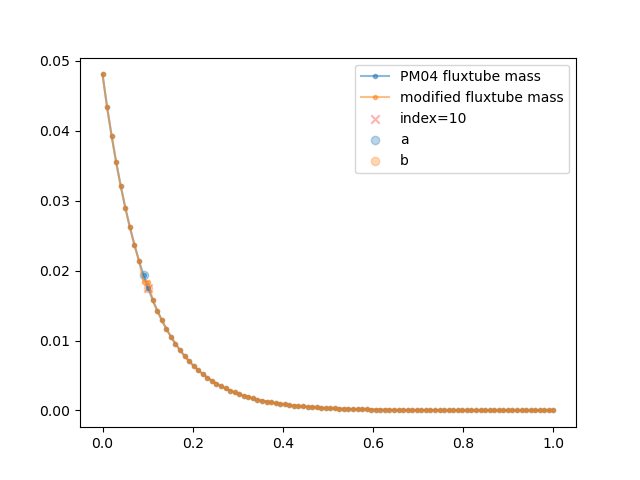

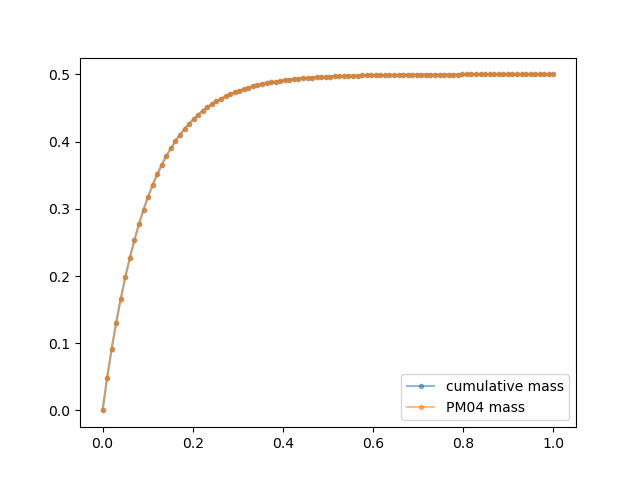

In [50]:
index = 10
cumulative_mass = np.array([simpson(pm04_dmdpsi[:i+1], x=psi[:i+1]/psi_0) for i in range(len(psi))])
cumulative_mass_to_index = np.array([simpson(pm04_dmdpsi[:i+1], x=psi[:i+1]/psi_0) for i in range(index+2)])
fluxtube_ab_masses = (cumulative_mass_to_index[1:] - cumulative_mass_to_index[:-1])[-2:]


fluxtube_masses = (cumulative_mass[1:] - cumulative_mass[:-1])

fluxtube_masses = np.append(fluxtube_masses,0)
print(np.sum(fluxtube_masses), cumulative_mass[-1])

# calculate mass that needs to move to equalise fluxtube masses
delta_mass_ab = 0.5*(fluxtube_ab_masses[0] - fluxtube_ab_masses[1])

adjusted_mass = np.zeros_like(psi)
adjusted_mass[index-1] -= delta_mass_ab
adjusted_mass[index] += delta_mass_ab
modified_fluxtube_mass = np.copy(fluxtube_masses)
modified_fluxtube_mass += adjusted_mass

fig,ax = plt.subplots()
ax.plot(psi/psi[-1], fluxtube_mass,'.-', alpha=0.5,label="PM04 fluxtube mass")
ax.plot(psi/psi[-1], modified_fluxtube_mass,'.-', alpha=0.5,label="modified fluxtube mass")
# ax.plot(psi/psi[-1], pm04_mass,'.-', alpha=0.5,label="PM04 mass")
ax.scatter(psi[index]/psi[-1],fluxtube_mass[index],c='r',marker='x',alpha=0.3, label=f"index={index}")
# ax.scatter(psi/psi[-1],fluxtube_masses, alpha=0.2,label="fluxtube masses")
ax.scatter(psi[index-1]/psi[-1],fluxtube_ab_masses[0], label="a", alpha=0.3)
ax.scatter(psi[index]/psi[-1],fluxtube_ab_masses[1],label='b', alpha = 0.3)
ax.legend()
plt.show()

fig,ax = plt.subplots()
ax.plot(psi/psi[-1], cumulative_mass,'.-', alpha=0.5,label="cumulative mass")
ax.plot(psi/psi[-1], pm04_mass,'.-', alpha=0.5,label="PM04 mass")
ax.legend()
plt.show()

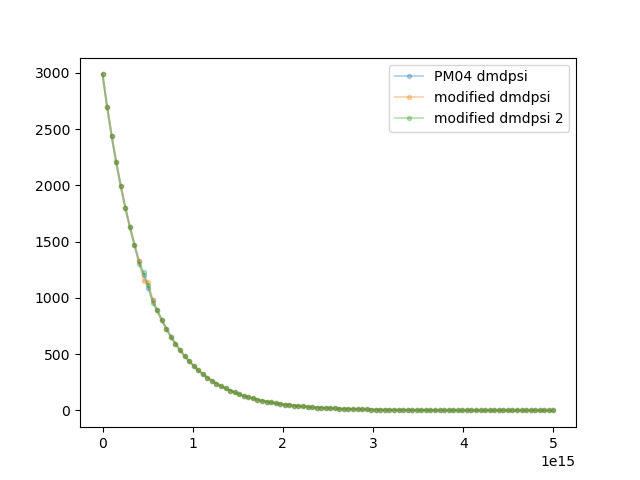

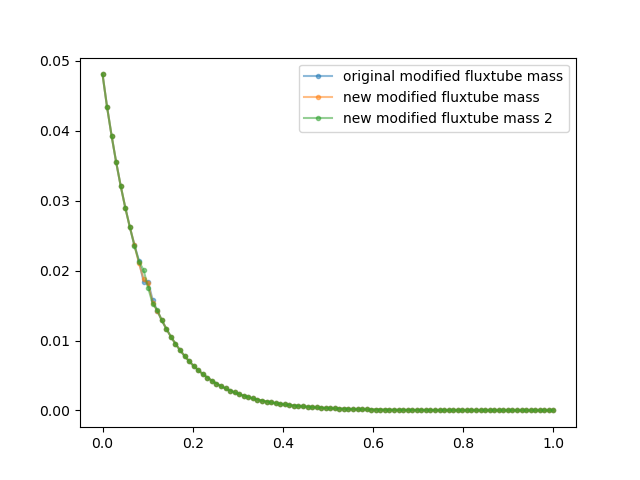

total mass (original) = 0.500000288712521, total mass (modified) = 0.500000288712521, total_mass (recalculated) = 0.49937985367695953
pct difference = 0.1242411024379894%


In [61]:
# now see how the modification affects dmdpsi, and whether we can recover the plot by integrating the modified dmdpsi

delta_m_delta_psi = adjusted_mass[:-1]/(psi[1:]-psi[:-1])*psi_0
delta_m_delta_psi = np.append(delta_m_delta_psi,0)
delta_m_delta_psi_2 = np.gradient(adjusted_mass,psi/psi_0,edge_order=1)

modified_dmdpsi = pm04_dmdpsi + delta_m_delta_psi
modified_dmdpsi_2 = pm04_dmdpsi + delta_m_delta_psi_2

new_cumulative_mass = np.array([simpson(modified_dmdpsi[:i+1], x=psi[:i+1]/psi_0) for i in range(len(psi))])
new_fluxtube_masses = (new_cumulative_mass[1:] - new_cumulative_mass[:-1])
new_fluxtube_masses = np.append(new_fluxtube_masses,0)

new_cumulative_mass_2 = np.array([simpson(modified_dmdpsi_2[:i+1], x=psi[:i+1]/psi_0) for i in range(len(psi))])
new_fluxtube_masses_2 = (new_cumulative_mass_2[1:] - new_cumulative_mass_2[:-1])
new_fluxtube_masses_2 = np.append(new_fluxtube_masses_2,0)

fig,ax = plt.subplots()
ax.plot(psi,pm04_dmdpsi,'.-',alpha=0.3,label="PM04 dmdpsi")
ax.plot(psi,modified_dmdpsi,'.-',alpha=0.3,label="modified dmdpsi")
ax.plot(psi,modified_dmdpsi_2,'.-',alpha=0.3,label="modified dmdpsi 2")
ax.legend()
plt.show()

fig,ax = plt.subplots()
ax.plot(psi/psi[-1], modified_fluxtube_mass,'.-', alpha=0.5,label="original modified fluxtube mass")
ax.plot(psi/psi[-1], new_fluxtube_masses,'.-', alpha=0.5,label="new modified fluxtube mass")
ax.plot(psi/psi[-1], new_fluxtube_masses_2,'.-', alpha=0.5,label="new modified fluxtube mass 2")
ax.legend()
plt.show()

print(f"total mass (original) = {np.sum(fluxtube_masses)}, total mass (modified) = {np.sum(modified_fluxtube_mass)}, total_mass (recalculated) = {np.sum(new_fluxtube_masses)}")
print(f"pct difference = {(np.sum(fluxtube_masses) - np.sum(new_fluxtube_masses))/np.sum(new_fluxtube_masses) * 100}%")

Therefore, when we calculate the amount of mass that needs to move between flux surfaces in a transport scheme, we integrate the dmdpsi profile using Simpson's 1/3 rule, and then modify the profile according to dmdpsi_new = dmdpsi_old + delta M / delta psi. When subsequently integrating the updated profile to again calculate the required mass, we find the discrepancy in the plot above.

0.09999551774690645 0.09999551774690645 0.09999551774690646


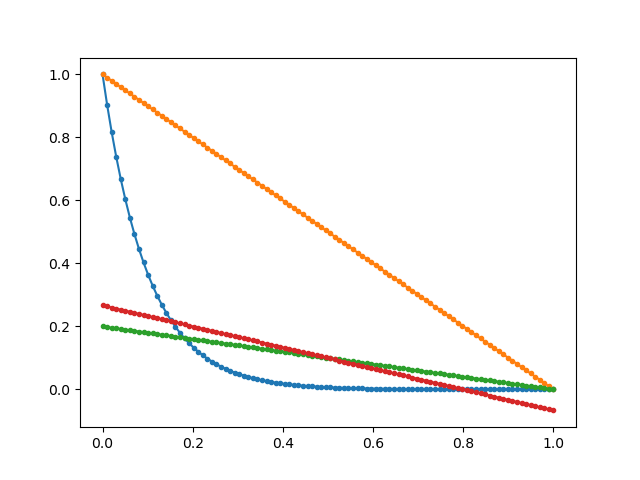

In [17]:
x = np.linspace(0,1,100)
y = np.exp(-x*10)

x0 = x[0]
x1 = x[-1]
y0 = y[0]
y1 = y[-1]

I0 = simpson(y,x)

gradient = (y1-y0)/(x1-x0)

y_adj_0 = y0 + gradient*(x - x0)

gradient_adj_1 = (I0 - y1*(x1 - x0))/(x1*x0 - 0.5*(x1**2 - x0**2))

y_adj_1 = y1 + gradient_adj_1*(x - x1)

I_adj_1 = simpson(y_adj_1,x)

gradient_adj_2 = gradient / 3

y0_adj_2 = (I0 - 0.5*gradient_adj_2*(x1**2 - x0**2) + gradient_adj_2*x0*(x1 + x0))/(x1-x0)

y_adj_2 = y0_adj_2 + gradient_adj_2*(x - x0)

I_adj_2 = simpson(y_adj_2,x)

print(I0,I_adj_1,I_adj_2)

fig,ax = plt.subplots()
ax.plot(x,y,'.-')
ax.plot(x,y_adj_0,'.-')
ax.plot(x,y_adj_1,'.-')
ax.plot(x,y_adj_2,'.-')
plt.show()
